In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from SI.DTM_SI import fixed_tuning_DTM_SI_randj
from TransMission.dtransmission import compute_debiased_beta_simple
from TransMission.transmission import noise_score_references

C:\Users\Admin\AppData\Local\Temp\ipykernel_8324\2315650167.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy import stats



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Ananconda\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Ananconda\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Ananconda\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Ananconda\Lib\site-packages\tornado\platform\asyncio.py", line 205, in 

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [ ]:
SEED = 185
P, NT, NS, K = 100, 30, 50, 2
SIGMA = 1.0
QUANTILE = 0.35    # noise-score quantile anchoring lambda_0 and lambda_T
N_REP = 1000

In [ ]:
design_rng, response_rng, feature_rng = (np.random.default_rng(s) for s in np.random.SeedSequence(SEED).spawn(3))

X0 = design_rng.standard_normal((NT, P))
X_list = [design_rng.standard_normal((NS, P)) for _ in range(K)]
ns_list = [NS] * K
Sigma_0 = SIGMA ** 2 * np.eye(NT)

lambda_0, lambda_T = noise_score_references(X0, X_list, sigma=SIGMA, quantile=QUANTILE, n_draws=5000, batch_size=250, seed=SEED + 1,)
print(f'lambda_0 = {lambda_0:.5f}   lambda_T = {lambda_T:.5f}')

lambda_0 = 0.22989   lambda_T = 0.44828


In [ ]:
def run(n_rep):
    p_values, branches, n_empty = [], [], 0

    for i in range(1, n_rep + 1):
        y0 = SIGMA * response_rng.standard_normal(NT)
        y_list = [SIGMA * response_rng.standard_normal(NS) for _ in range(K)]
        beta_tilde = [compute_debiased_beta_simple(Xk, yk) for Xk, yk in zip(X_list, y_list)]

        result = fixed_tuning_DTM_SI_randj(X0, y0, beta_tilde, ns_list, lambda_0, lambda_T, Sigma_0, rng=feature_rng,)

        if result['results']:
            p_values.append(result['results'][0]['p_value'])
            branches.append(result['branch'])
        else:
            n_empty += 1

        if i % 100 == 0:
            print(f'{i}/{n_rep}  kept {len(p_values)}', flush=True)

    return np.array(p_values), branches, n_empty

In [5]:
p_values, branches, n_empty = run(N_REP)

100/1000  kept 65


200/1000  kept 131


300/1000  kept 207


400/1000  kept 277


500/1000  kept 340


600/1000  kept 408


700/1000  kept 477


800/1000  kept 546


900/1000  kept 621


1000/1000  kept 680


In [ ]:
print(f'tests: {p_values.size} replications with an empty model: {n_empty}')
print('branches:', {b: branches.count(b) for b in sorted(set(branches))})

tests: 680    replications with an empty model: 320
branches: {'fallback': 679, 'transmission': 1}


In [7]:
alpha = 0.05
FPR = np.mean(p_values <= alpha)
print(f"FPR = {FPR}")

FPR = 0.045588235294117645


In [8]:
statistic, p_value = stats.kstest(p_values, 'uniform')
print(f'KS-Test statistic = {statistic}')
print(f'KS-Test p-value = {p_value}')

KS-Test statistic = 0.026730150008656917
KS-Test p-value = 0.7057226273924068


(array([34., 31., 37., 29., 28., 33., 33., 37., 30., 39., 32., 30., 41.,
        29., 44., 31., 31., 41., 34., 36.]),
 array([0.00172897, 0.05164098, 0.10155299, 0.151465  , 0.20137701,
        0.25128903, 0.30120104, 0.35111305, 0.40102506, 0.45093707,
        0.50084908, 0.55076109, 0.6006731 , 0.65058511, 0.70049712,
        0.75040913, 0.80032114, 0.85023315, 0.90014516, 0.95005717,
        0.99996918]),
 <BarContainer object of 20 artists>)

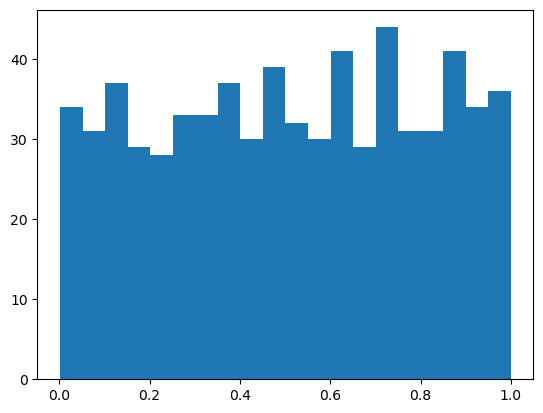

In [9]:
plt.hist(p_values, bins=20)

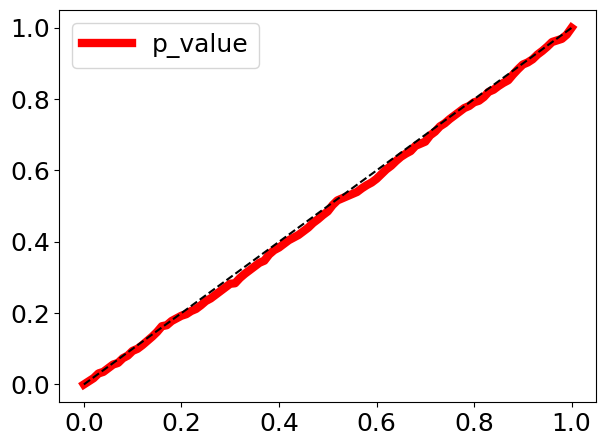

In [10]:
plt.rcParams.update({'font.size': 18})
grid = np.linspace(0, 1, 101)
ecdf = np.searchsorted(np.sort(p_values), grid, side='right') / len(p_values)
plt.plot(grid, ecdf, 'r-', linewidth=6, label='p_value')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.tight_layout()
plt.show()